In [1]:
# %pip install scikit-learn
# %pip install nbconvert
# %jupyter nbconvert --to script test.ipynb

In [2]:
# scipy.ndimage.median_filter
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

import INUVisionLib as ivl

print("\n라이브러리 로드")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

라이브러리 로드


# **[시작] 카메라 호출**

### 카메라 설정

[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
✅ Preset 설정 완료: High Density
✅ Depth Unit 설정 완료: 9.999999747378752e-05
✅ 뎁스 센서 자동 노출(AE) 스위치 ON
✅ Depth ROI 영역 설정 완료 (중앙 40% / X: 254~593, Y: 144~336)
✅ 레이저 파워 설정 완료: 250
✅ Disparity Shift 설정 완료: 0
✅ Temporal Filter 설정 완료
✅ Threshold Filter 설정 완료 (최소: 0.2m, 최대: 0.8m)
✅ 컬러 센서 자동 화이트 밸런스(AWB) ON
🔥 센서 안정화 중... (30 프레임 대기)


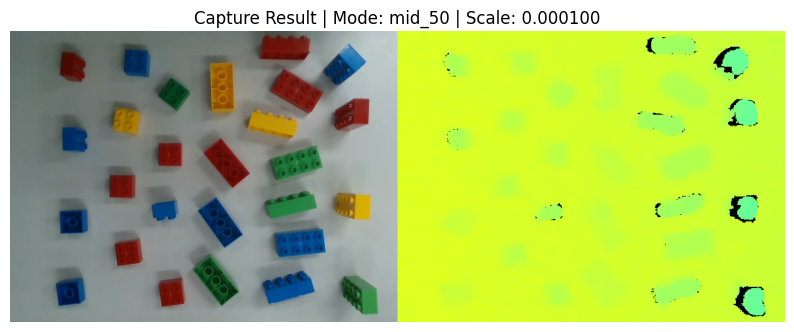

✅ 카메라 스트리밍 안전 종료 완료.


In [3]:
# 카메라 연결 확인
devices = ivl.get_realsense_ids()
target_serial = list(devices.keys())[0]

# 8비트 RGB 이미지, 16비트 뎁스, 인트린직, 뎁스 스케일 출력
# 카메라 모드 별로 설정 변경 가능

color_rgb, depth, intrinsics, scale = ivl.capture_realsense_data(
    serial_number=target_serial, 
    mode="mid_50", 
    visualize=True
)

color_img_bgr = color_rgb.copy()
color_img_bgr = cv2.cvtColor(color_img_bgr, cv2.COLOR_RGB2BGR)

# color_img_rgb (ndarray): RGB 포맷의 컬러 이미지 (YOLO, Open3D용)
# depth_img (ndarray): Raw 뎁스 이미지
# intrinsics (rs.intrinsics): 카메라 내부 파라미터 (3D 투영용)
# depth_scale (float): 뎁스 단위를 미터(m)로 변환하기 위한 스케일 값 (매우 중요)

# **욜로 인지**

### **YOLO V8 세그멘테이션 기준 영역 잡기**

🎯 [SUCCESS] 29개의 타겟 객체 마스크 병합 완료


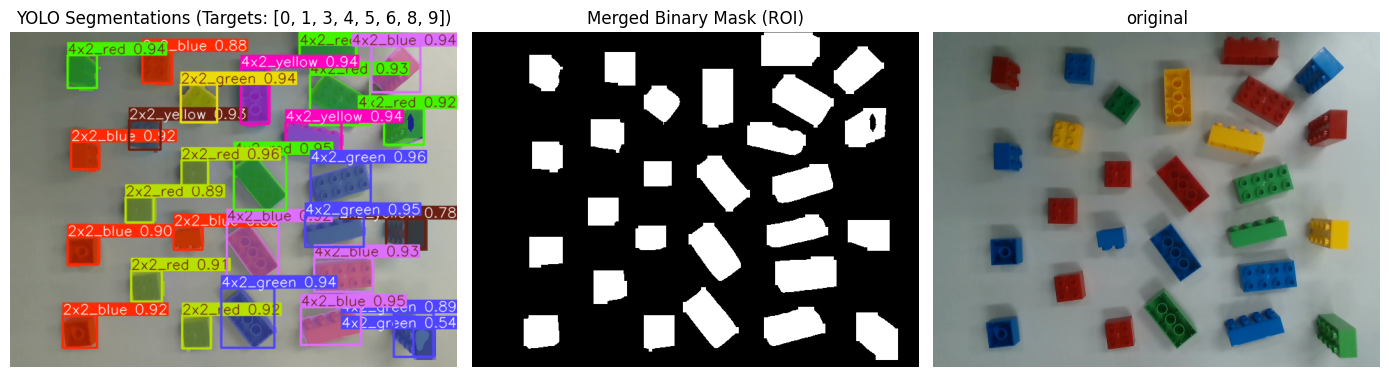

In [4]:
# color_rgb, depth, intrinsics, scale

# 욜로 검출
model = YOLO("yolo_models/duplo_2_low_2/weights/best.pt")
# model = YOLO("yolo_models/manip_segmentor_0528.pt")
target_classes = [0, 1, 3, 4, 5, 6, 8, 9]

results, mask_binary, vis_yolo = ivl.detect_objects_yolo(
    model= model, 
    color_img_bgr=color_img_bgr, 
    target_classes=target_classes, 
    visualize=True
)

# results (list): YOLO 모델의 원본 추론 결과 객체 리스트
# mask_binary (ndarray): 검출된 모든 객체의 마스크를 하나로 합친 이진 마스크 (0 or 1, 형태: H x W)
# vis_yolo (ndarray): 바운딩 박스와 라벨이 그려진 시각화용 이미지 (BGR)

### 바운딩 박스가 겹치는 부분을 억제하는 전처리 추가

✂️ [INFO] 억제됨: '2x2_yellow' (면적:1408)가 '2x2_yellow' (면적:2391)에 99.4% 포함됨.

✅ 최종 검출된 유효 객체/군집 수: 28개
 - 🏷️ 4x2_blue (신뢰도: 0.93)
 - 🏷️ 4x2_red (신뢰도: 0.82)
 - 🏷️ 4x2_red (신뢰도: 0.93)
 - 🏷️ 4x2_yellow (신뢰도: 0.94)
 - 🏷️ 4x2_green (신뢰도: 0.94)
 - 🏷️ 4x2_blue (신뢰도: 0.92)
 - 🏷️ 4x2_blue (신뢰도: 0.95)
 - 🏷️ 4x2_green (신뢰도: 0.96)
 - 🏷️ 4x2_red (신뢰도: 0.95)
 - 🏷️ 4x2_yellow (신뢰도: 0.94)
 - 🏷️ 4x2_green (신뢰도: 0.95)
 - 🏷️ 4x2_blue (신뢰도: 0.94)
 - 🏷️ 4x2_green (신뢰도: 0.89)
 - 🏷️ 4x2_red (신뢰도: 0.92)
 - 🏷️ 2x2_yellow (신뢰도: 0.78)
 - 🏷️ 2x2_blue (신뢰도: 0.92)
 - 🏷️ 2x2_red (신뢰도: 0.92)
 - 🏷️ 2x2_red (신뢰도: 0.91)
 - 🏷️ 2x2_blue (신뢰도: 0.88)
 - 🏷️ 4x2_red (신뢰도: 0.94)
 - 🏷️ 2x2_yellow (신뢰도: 0.93)
 - 🏷️ 2x2_blue (신뢰도: 0.90)
 - 🏷️ 2x2_green (신뢰도: 0.94)
 - 🏷️ 2x2_blue (신뢰도: 0.92)
 - 🏷️ 2x2_red (신뢰도: 0.89)
 - 🏷️ 2x2_blue (신뢰도: 0.86)
 - 🏷️ 2x2_red (신뢰도: 0.96)
 - 🏷️ 4x2_green (신뢰도: 0.54)


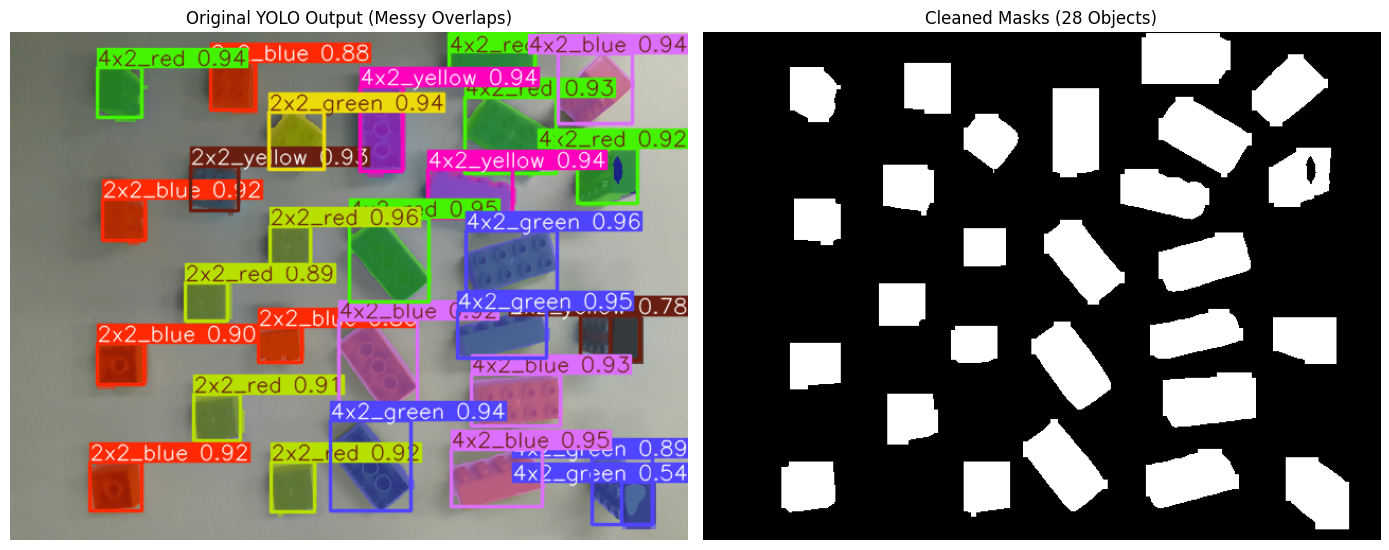


✅ 최종 검출된 유효 객체/군집 수: 28개
 - Name: 4x2_blue
 - Name: 4x2_red
 - Name: 4x2_red
 - Name: 4x2_yellow
 - Name: 4x2_green
 - Name: 4x2_blue
 - Name: 4x2_blue
 - Name: 4x2_green
 - Name: 4x2_red
 - Name: 4x2_yellow
 - Name: 4x2_green
 - Name: 4x2_blue
 - Name: 4x2_green
 - Name: 4x2_red
 - Name: 2x2_yellow
 - Name: 2x2_blue
 - Name: 2x2_red
 - Name: 2x2_red
 - Name: 2x2_blue
 - Name: 4x2_red
 - Name: 2x2_yellow
 - Name: 2x2_blue
 - Name: 2x2_green
 - Name: 2x2_blue
 - Name: 2x2_red
 - Name: 2x2_blue
 - Name: 2x2_red
 - Name: 4x2_green


In [5]:
# 겹치는 마스크 깔끔하게 정리 (해상도 640x480 기준, 70% 겹치면 삭제, 시각화 켬)
final_objects, clean_mask = ivl.filter_overlapping_masks(
    results=results, 
    overlap_threshold=0.70, 
    img_shape=(640, 480), 
    visualize=True
)

# final_detected_objects (list): 억제 후 살아남은 최종 객체들의 리스트. 
#                                 각 요소는 dict 형태 (class_id, class_name, confidence, mask)
# final_combined_mask (ndarray): 병합된 최종 전체 ROI 마스크 (0 or 1, uint8)

print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_objects)}개")
final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
for obj in final_objects:
    print(f" - Name: {obj['class_name']}")
    final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)

### Ransac 바닥 검출 후 높이 + 비율 기반 ID 수정

In [11]:
import copy

# 1. 이전 단계에서 얻은 데이터: 
# color_rgb, depth, intrinsics, scale
# final_objects, clean_mask

# =================================================================
# [STEP 1 & 2 통합] DBSCAN+RANSAC 바닥 추정 및 40mm 돌출 맵 사영
# =================================================================
# 기존의 바닥 다림질과 돌출 맵 추출 과정이 하나의 함수로 처리됩니다.
# 반환된 closed_mask가 곧 40mm 이상 돌출된 객체의 2D 마스크(mask_40mm_2d)입니다.
mask_40mm_2d, refined_color, contours, plane_model = ivl.extract_3d_protruding_objects(
    depth_img=depth, 
    color_img_bgr=color_img_bgr, 
    intrinsics=intrinsics, 
    depth_scale=scale, 
    yolo_combined_mask=clean_mask,
    depth_trunc=5.0,
    height_threshold=0.040,
    visualize=False
)

# print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_objects)}개")
# final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
# for obj in final_objects:
#     print(f" - Name: {obj['class_name']}")
#     final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)

# =================================================================
# [STEP 3] 최종 OBB 기반 ID 판독 및 교정
# =================================================================

final_objects_before = copy.deepcopy(final_objects)

final_objects, result_vis_img = ivl.correct_object_ids(
    detected_objects=final_objects, 
    mask_high_2d=mask_40mm_2d, 
    color_img_bgr=color_img_bgr, 
    ratio_threshold=1.5, 
    overlap_threshold=0.20, 
    visualize=False
)

final_objects_after = copy.deepcopy(final_objects)


for i, obj in enumerate(final_objects_after):
    print(i, obj.keys())
    print("class:", obj["class_name"])
    print("mask shape:", obj["mask"].shape, "dtype:", obj["mask"].dtype, "unique:", np.unique(obj["mask"])[:10])
    print()



# =================================================================
# [STEP 3-1] ID 교정 후 마스크 내부 채우기
# =================================================================

objects_filled = copy.deepcopy(final_objects_after)

mask_before = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)
mask_after = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)

for obj in objects_filled:
    # 기존 객체 마스크
    original_mask = (obj["mask"] > 0).astype(np.uint8)

    # 내부 구멍 채우기
    filled_mask = ivl.fill_object_mask_holes(original_mask)

    # 객체별 mask를 채운 결과로 교체
    # bool로 유지하고 싶으면 이 방식 추천
    obj["mask"] = filled_mask.astype(bool)

    # 전체 before / after 통합 마스크 생성
    mask_before = np.logical_or(mask_before, original_mask > 0).astype(np.uint8)
    mask_after = np.logical_or(mask_after, filled_mask > 0).astype(np.uint8)


[INFO] 3D 기반 돌출 객체 추출 및 2D 마스킹 파이프라인 시작...
✅ 바닥 평면 도출 성공: 0.023x + -0.003y + 1.000z + 0.530 = 0
✅ 40.0mm 이상 돌출된 객체 포인트: 553개

[INFO] 객체 마스크 기반 OBB 추출 및 물리적 조건 기반 ID 교정 중...
0 dict_keys(['class_id', 'class_name', 'confidence', 'mask'])
class: 4x2_blue
mask shape: (480, 640) dtype: bool unique: [False  True]

1 dict_keys(['class_id', 'class_name', 'confidence', 'mask'])
class: 4x2_red
mask shape: (480, 640) dtype: bool unique: [False  True]

2 dict_keys(['class_id', 'class_name', 'confidence', 'mask'])
class: 4x2_red
mask shape: (480, 640) dtype: bool unique: [False  True]

3 dict_keys(['class_id', 'class_name', 'confidence', 'mask'])
class: 4x2_yellow
mask shape: (480, 640) dtype: bool unique: [False  True]

4 dict_keys(['class_id', 'class_name', 'confidence', 'mask'])
class: 4x2_green
mask shape: (480, 640) dtype: bool unique: [False  True]

5 dict_keys(['class_id', 'class_name', 'confidence', 'mask'])
class: 4x2_blue
mask shape: (480, 640) dtype: bool unique: [False  True]

6 dict_ke

### 디버깅용 - 어떤 객체가 변경되었는지 하이라이트


[ID 변경 목록]
변경된 객체 없음


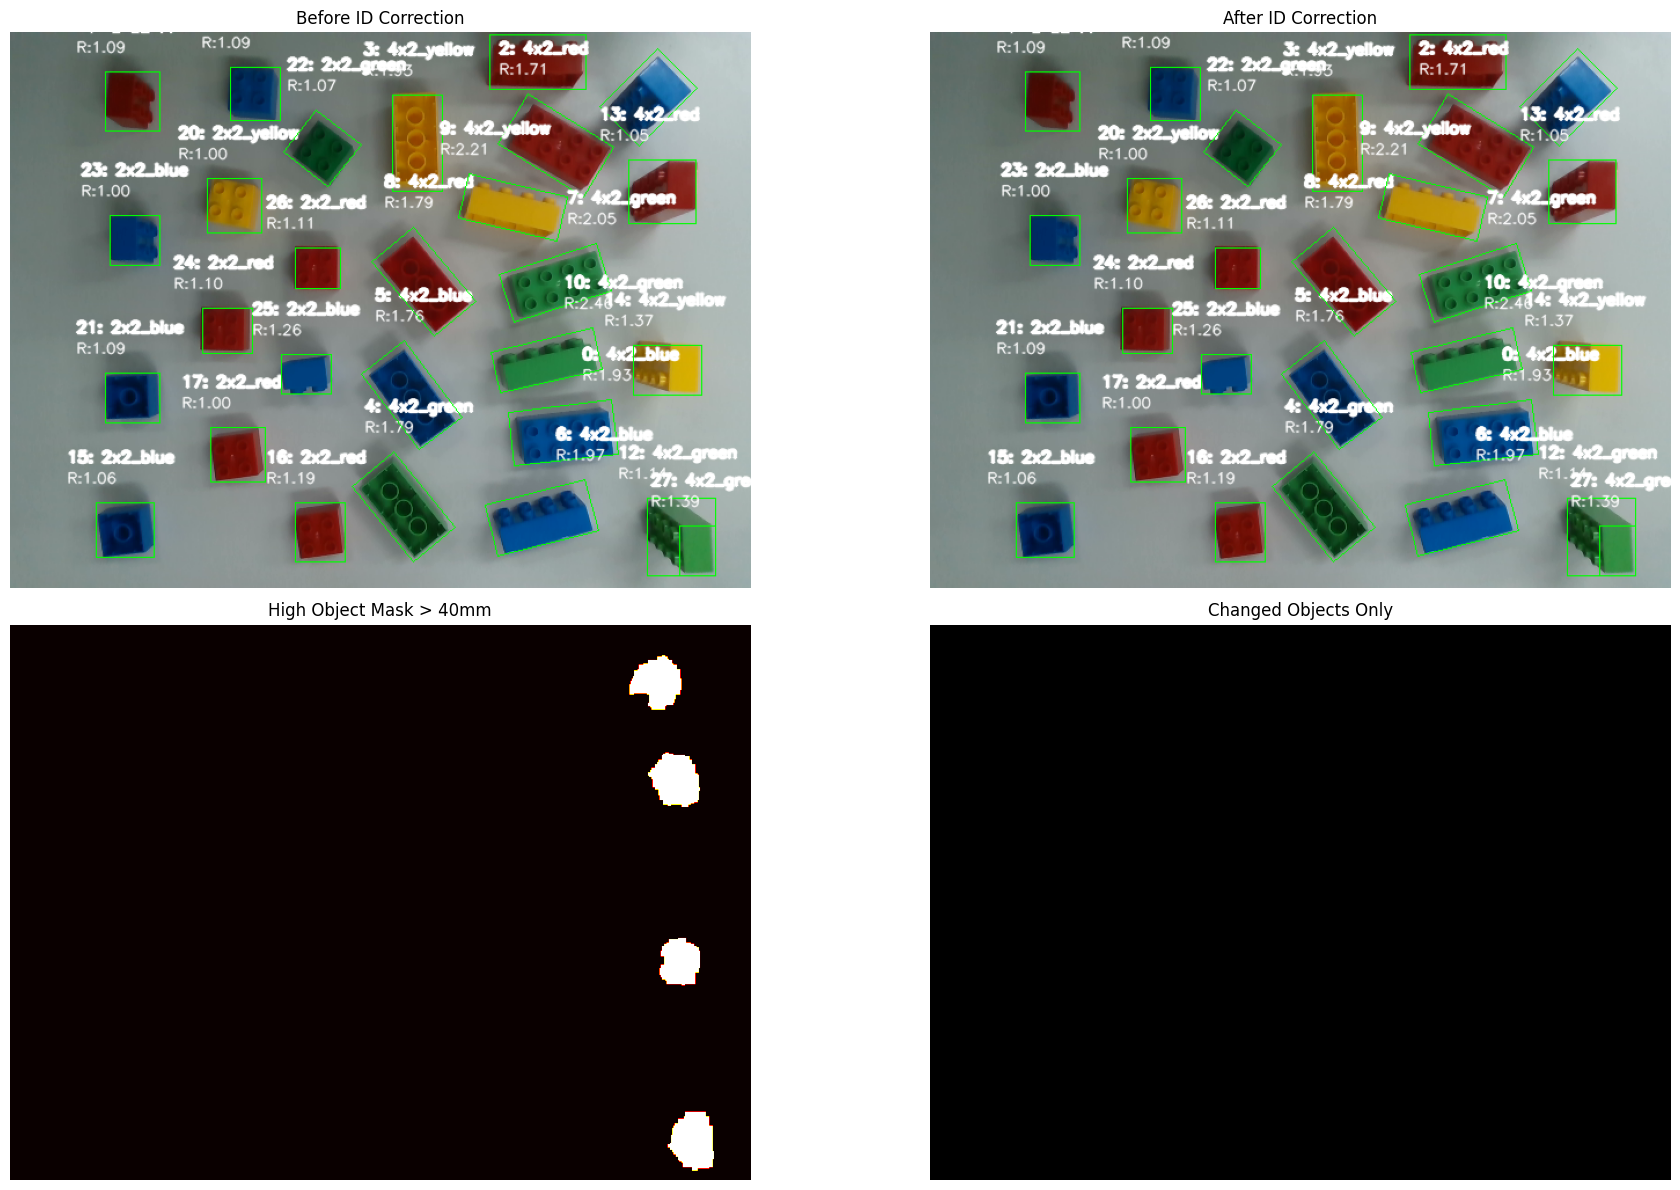

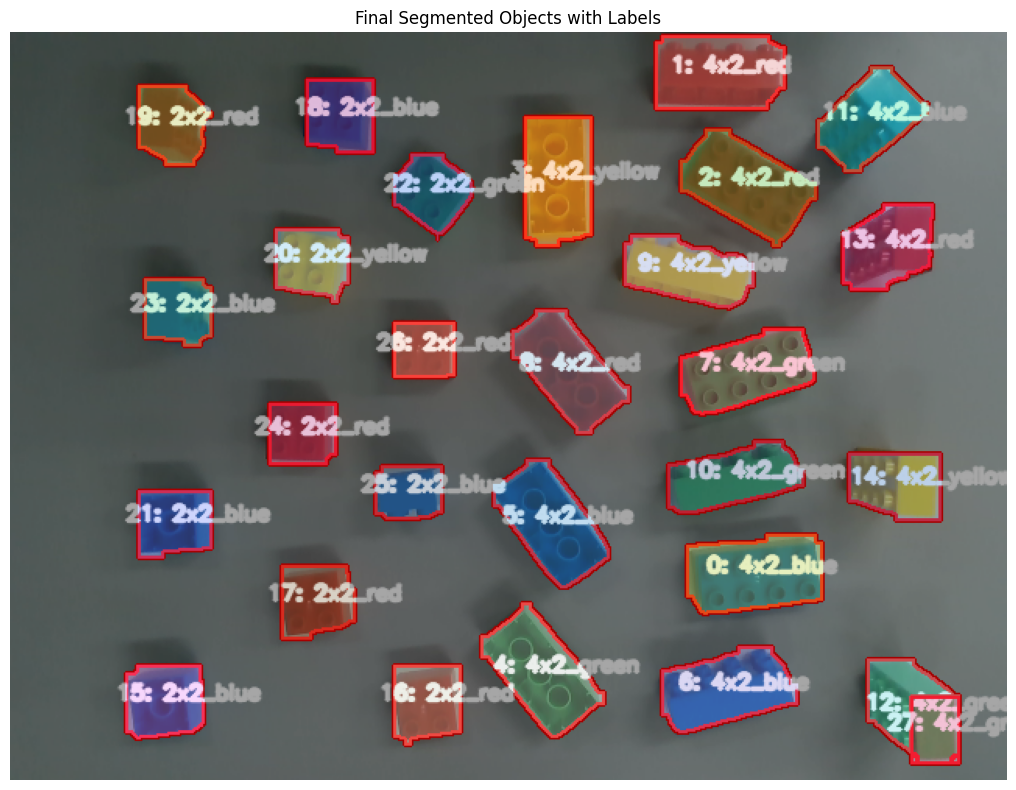

In [13]:
vis_result = ivl.visualize_id_correction_and_final_segments(
    color_img_bgr=color_img_bgr,
    final_objects_before=final_objects_before,
    final_objects_after=objects_filled,
    mask_40mm_2d=mask_40mm_2d,
    show=True
)


[INFO] 3D Scene 분석 및 높이별 2D 마스크 추출 시작...

[INFO] YOLO 융합, ID 교정 및 3D 바운딩 박스 생성 중...
 🎯 [높이 강제 고정] 가장 낮은 객체('[C]4x2_green') 높이: 8.4mm -> 24.0mm


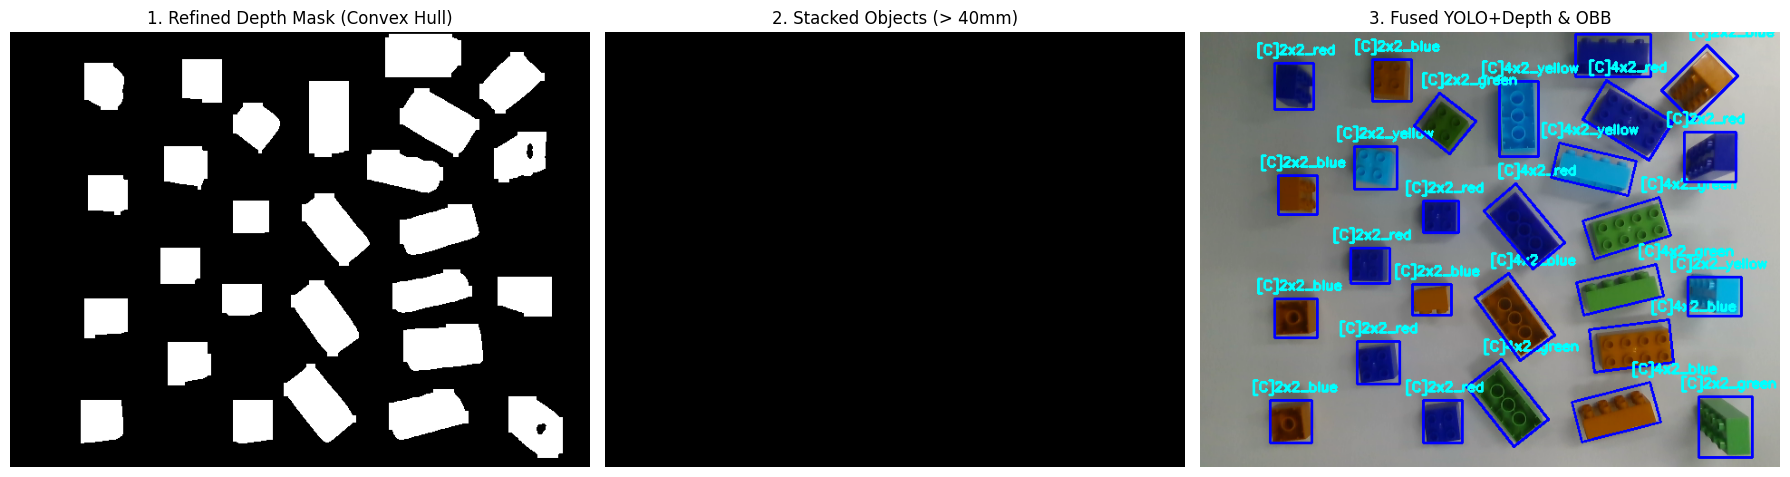


[INFO] 1번 창(분석용 색상 클러스터)을 엽니다. 창을 닫으면 원본 맵이 열립니다.
[INFO] 2번 창(원본 RGB-D 오버레이)을 엽니다.


In [ ]:
# # =================================================================
# # [FINAL PIPELINE] 3D OBB용 실행부
# # =================================================================

# # 1. 높이별 depth mask + pcd data 생성
# mask_5mm_2d, mask_40mm_2d, pcd_data, plane_data, floor_pcd = ivl.process_scene_and_get_height_masks(
#     depth_img=depth,
#     intrinsics=intrinsics,
#     depth_scale=scale,
#     color_img_shape=color_rgb.shape
# )

# # 2. refined mask 준비
# # 이미 refined_mask_01이 있으면 그걸 사용
# # 없으면 YOLO final mask를 임시 refined mask로 사용
# refined_mask_01 = np.zeros(color_rgb.shape[:2], dtype=np.uint8)

# for obj in final_objects:
#     refined_mask_01 = np.logical_or(
#         refined_mask_01,
#         obj["mask"].astype(bool)
#     ).astype(np.uint8)

# # 3. YOLO + Depth 융합, ID 교정, 3D OBB 생성
# final_objects_3d, vis_3d, overlay_3d, vis_2d_rgb, mask_high, mask_low = ivl.fuse_yolo_and_generate_3d_obbs(
#     detected_objects=final_objects,
#     refined_mask_01=refined_mask_01,
#     mask_40mm_2d=mask_40mm_2d,
#     pcd_data=pcd_data,
#     plane_data=plane_data,
#     intrinsics=intrinsics,
#     color_img_rgb=color_rgb,
#     floor_pcd=floor_pcd
# )

# # 4. 최종 시각화
# ivl.visualize_final_rgbd_pointcloud(
#     color_img_rgb=color_rgb,
#     depth_img=depth,
#     intrinsics=intrinsics,
#     depth_scale=scale,
#     refined_mask_01=refined_mask_01,
#     mask_high_vis=mask_high,
#     vis_image_2d=vis_2d_rgb,
#     vis_elements_3d=vis_3d,
#     overlay_geometries_3d=overlay_3d
# )

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

# ============================================================
# Hough Circle 검출 함수
# ============================================================
def detect_hough_circles_in_objects(
    color_img_bgr,
    objects,
    dp=1.2,
    min_dist=18,
    param1=80,
    param2=18,
    min_radius=4,
    max_radius=18,
    blur_ksize=5,
    morph_close=True,
    show=True
):
    """
    객체별 mask 영역만 color image와 AND 연산한 뒤,
    각 객체 ROI 내부에서 Hough Circle 검출.

    Args:
        color_img_bgr: BGR 원본 이미지
        objects: final_objects_after 또는 objects_filled
        dp, min_dist, param1, param2, min_radius, max_radius: cv2.HoughCircles 파라미터
        blur_ksize: median blur kernel size
        morph_close: mask를 한 번 close해서 안정화할지 여부
        show: 결과 시각화 여부

    Returns:
        circle_results: 객체별 circle 검출 결과 리스트
        vis_all_bgr: 전체 원본 위 circle 표시 이미지
        masked_color_bgr: 전체 mask AND 결과 이미지
    """

    h, w = color_img_bgr.shape[:2]

    # ------------------------------------------------------------
    # 1. 전체 마스크 생성
    # ------------------------------------------------------------
    final_mask_01 = np.zeros((h, w), dtype=np.uint8)

    for obj in objects:
        mask = (obj["mask"] > 0).astype(np.uint8)
        final_mask_01 = np.logical_or(final_mask_01, mask > 0).astype(np.uint8)

    if morph_close:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        final_mask_01 = cv2.morphologyEx(final_mask_01, cv2.MORPH_CLOSE, kernel)

    final_mask_255 = (final_mask_01 * 255).astype(np.uint8)

    # ------------------------------------------------------------
    # 2. 전체 결과 마스크와 컬러 이미지 AND
    # ------------------------------------------------------------
    masked_color_bgr = cv2.bitwise_and(
        color_img_bgr,
        color_img_bgr,
        mask=final_mask_255
    )

    vis_all_bgr = color_img_bgr.copy()
    vis_masked_bgr = masked_color_bgr.copy()

    circle_results = []
    per_object_vis_list = []

    # ------------------------------------------------------------
    # 3. 객체별 Hough Circle
    # ------------------------------------------------------------
    for idx, obj in enumerate(objects):
        class_name = obj["class_name"]
        obj_mask_01 = (obj["mask"] > 0).astype(np.uint8)

        if morph_close:
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
            obj_mask_01 = cv2.morphologyEx(obj_mask_01, cv2.MORPH_CLOSE, kernel)

        obj_mask_255 = (obj_mask_01 * 255).astype(np.uint8)

        contours, _ = cv2.findContours(
            obj_mask_255,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if len(contours) == 0:
            circle_results.append({
                "idx": idx,
                "class_name": class_name,
                "circles": []
            })
            continue

        largest_contour = max(contours, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(largest_contour)

        # 약간 padding
        pad = 8
        x1 = max(x - pad, 0)
        y1 = max(y - pad, 0)
        x2 = min(x + bw + pad, w)
        y2 = min(y + bh + pad, h)

        roi_color = color_img_bgr[y1:y2, x1:x2].copy()
        roi_mask = obj_mask_255[y1:y2, x1:x2].copy()

        # 객체 영역만 AND
        roi_masked = cv2.bitwise_and(
            roi_color,
            roi_color,
            mask=roi_mask
        )

        # --------------------------------------------------------
        # Gray 변환 후 배경 제거
        # --------------------------------------------------------
        roi_gray = cv2.cvtColor(roi_masked, cv2.COLOR_BGR2GRAY)

        # mask 바깥은 0이라 Hough에 영향 가능 → 살짝 blur
        if blur_ksize % 2 == 0:
            blur_ksize += 1

        roi_gray_blur = cv2.medianBlur(roi_gray, blur_ksize)

        # --------------------------------------------------------
        # Hough Circle 검출
        # --------------------------------------------------------
        circles = cv2.HoughCircles(
            roi_gray_blur,
            cv2.HOUGH_GRADIENT,
            dp=dp,
            minDist=min_dist,
            param1=param1,
            param2=param2,
            minRadius=min_radius,
            maxRadius=max_radius
        )

        obj_circles = []

        roi_vis = roi_masked.copy()

        if circles is not None:
            circles = np.round(circles[0, :]).astype(int)

            for c in circles:
                cx_roi, cy_roi, r = c

                # ROI 내부 좌표 → 전체 이미지 좌표
                cx = int(cx_roi + x1)
                cy = int(cy_roi + y1)

                # 원 중심이 실제 객체 mask 안쪽인지 확인
                if cx < 0 or cx >= w or cy < 0 or cy >= h:
                    continue

                if obj_mask_01[cy, cx] == 0:
                    continue

                obj_circles.append({
                    "center": (cx, cy),
                    "radius": int(r),
                    "center_roi": (int(cx_roi), int(cy_roi))
                })

                # 전체 이미지에 표시
                cv2.circle(vis_all_bgr, (cx, cy), int(r), (0, 255, 255), 2)
                cv2.circle(vis_all_bgr, (cx, cy), 2, (0, 0, 255), -1)

                # masked 이미지에도 표시
                cv2.circle(vis_masked_bgr, (cx, cy), int(r), (0, 255, 255), 2)
                cv2.circle(vis_masked_bgr, (cx, cy), 2, (0, 0, 255), -1)

                # ROI 이미지에 표시
                cv2.circle(roi_vis, (int(cx_roi), int(cy_roi)), int(r), (0, 255, 255), 2)
                cv2.circle(roi_vis, (int(cx_roi), int(cy_roi)), 2, (0, 0, 255), -1)

        # OBB/Contour 및 라벨 표시
        cv2.rectangle(vis_all_bgr, (x1, y1), (x2, y2), (0, 255, 0), 1)
        cv2.putText(
            vis_all_bgr,
            f"{idx}: {class_name} C:{len(obj_circles)}",
            (x1, max(y1 - 5, 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

        cv2.putText(
            roi_vis,
            f"{idx}: {class_name} / circles:{len(obj_circles)}",
            (5, 18),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

        circle_results.append({
            "idx": idx,
            "class_name": class_name,
            "bbox": (x1, y1, x2, y2),
            "circles": obj_circles
        })

        per_object_vis_list.append(roi_vis)

    # ------------------------------------------------------------
    # 4. 출력 로그
    # ------------------------------------------------------------
    print("\n[Hough Circle 검출 결과]")
    total_circles = 0

    for item in circle_results:
        n = len(item["circles"])
        total_circles += n
        print(f" - idx {item['idx']:02d} | {item['class_name']} | circles: {n}")

    print(f"\n✅ 전체 검출 circle 수: {total_circles}")

    # ------------------------------------------------------------
    # 5. 시각화
    # ------------------------------------------------------------
    if show:
        plt.figure(figsize=(20, 7))

        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB))
        plt.title("Original Color")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(cv2.cvtColor(masked_color_bgr, cv2.COLOR_BGR2RGB))
        plt.title("Color AND Final Mask")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(vis_all_bgr, cv2.COLOR_BGR2RGB))
        plt.title("Hough Circles on Original")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 7))
        plt.imshow(cv2.cvtColor(vis_masked_bgr, cv2.COLOR_BGR2RGB))
        plt.title("Hough Circles on Masked Color")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        # 객체별 ROI 결과 grid
        if len(per_object_vis_list) > 0:
            n = len(per_object_vis_list)
            cols = 5
            rows = math.ceil(n / cols)

            plt.figure(figsize=(cols * 4, rows * 3))

            for i, roi_vis in enumerate(per_object_vis_list):
                plt.subplot(rows, cols, i + 1)
                plt.imshow(cv2.cvtColor(roi_vis, cv2.COLOR_BGR2RGB))
                plt.title(f"Obj {i}")
                plt.axis("off")

            plt.tight_layout()
            plt.show()

    return circle_results, vis_all_bgr, masked_color_bgr, vis_masked_bgr


[Hough Circle 검출 결과]
 - idx 00 | 4x2_blue | circles: 1
 - idx 01 | 4x2_red | circles: 0
 - idx 02 | 4x2_red | circles: 1
 - idx 03 | 4x2_yellow | circles: 2
 - idx 04 | 4x2_green | circles: 1
 - idx 05 | 4x2_blue | circles: 0
 - idx 06 | 4x2_blue | circles: 0
 - idx 07 | 4x2_green | circles: 0
 - idx 08 | 4x2_red | circles: 0
 - idx 09 | 4x2_yellow | circles: 0
 - idx 10 | 4x2_green | circles: 1
 - idx 11 | 4x2_blue | circles: 0
 - idx 12 | 4x2_green | circles: 0
 - idx 13 | 4x2_red | circles: 0
 - idx 14 | 4x2_yellow | circles: 0
 - idx 15 | 2x2_blue | circles: 0
 - idx 16 | 2x2_red | circles: 0
 - idx 17 | 2x2_red | circles: 0
 - idx 18 | 2x2_blue | circles: 1
 - idx 19 | 2x2_red | circles: 1
 - idx 20 | 2x2_yellow | circles: 1
 - idx 21 | 2x2_blue | circles: 0
 - idx 22 | 2x2_green | circles: 1
 - idx 23 | 2x2_blue | circles: 0
 - idx 24 | 2x2_red | circles: 1
 - idx 25 | 2x2_blue | circles: 0
 - idx 26 | 2x2_red | circles: 0
 - idx 27 | 4x2_green | circles: 0

✅ 전체 검출 circle 수: 11

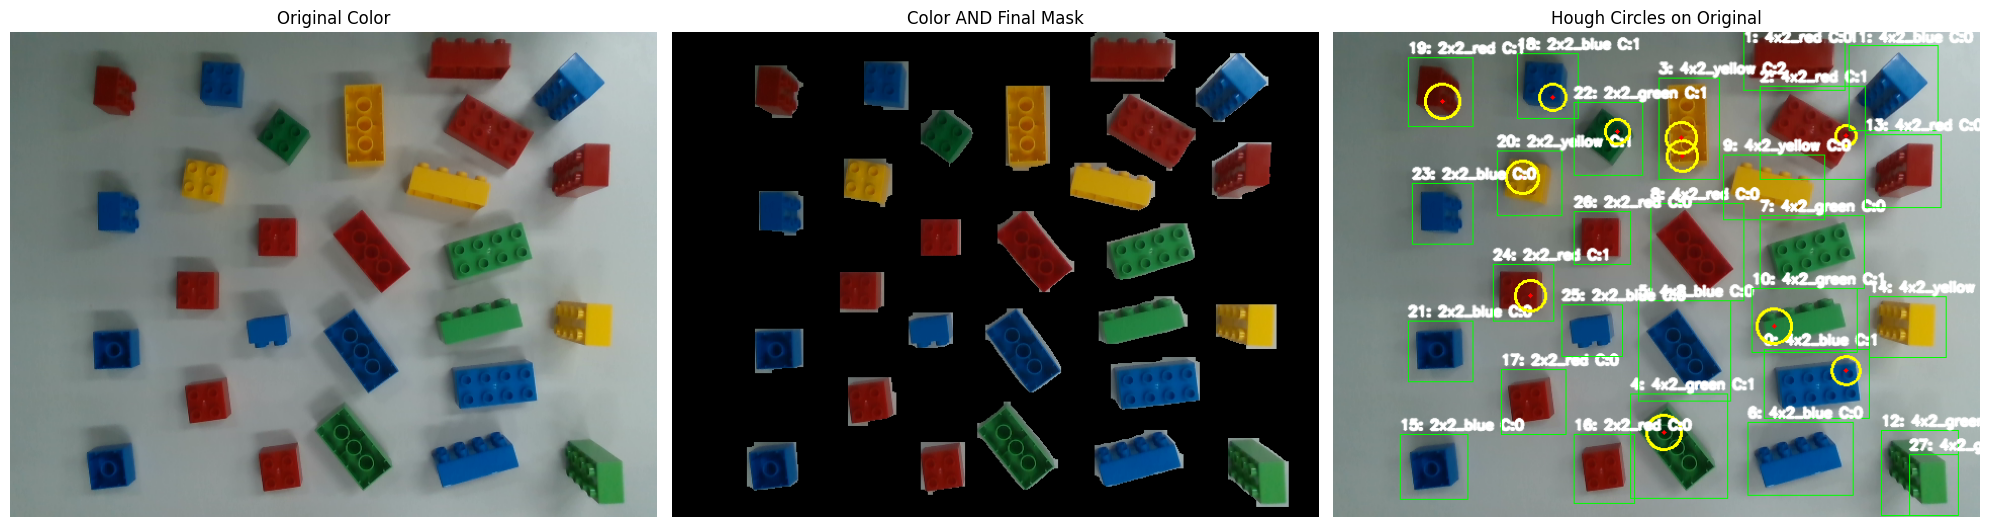

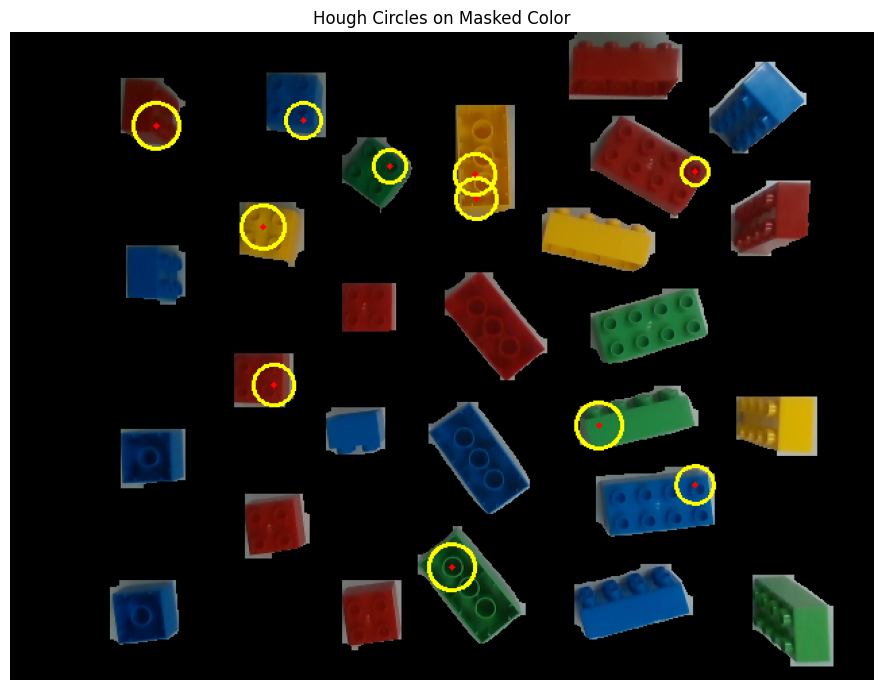

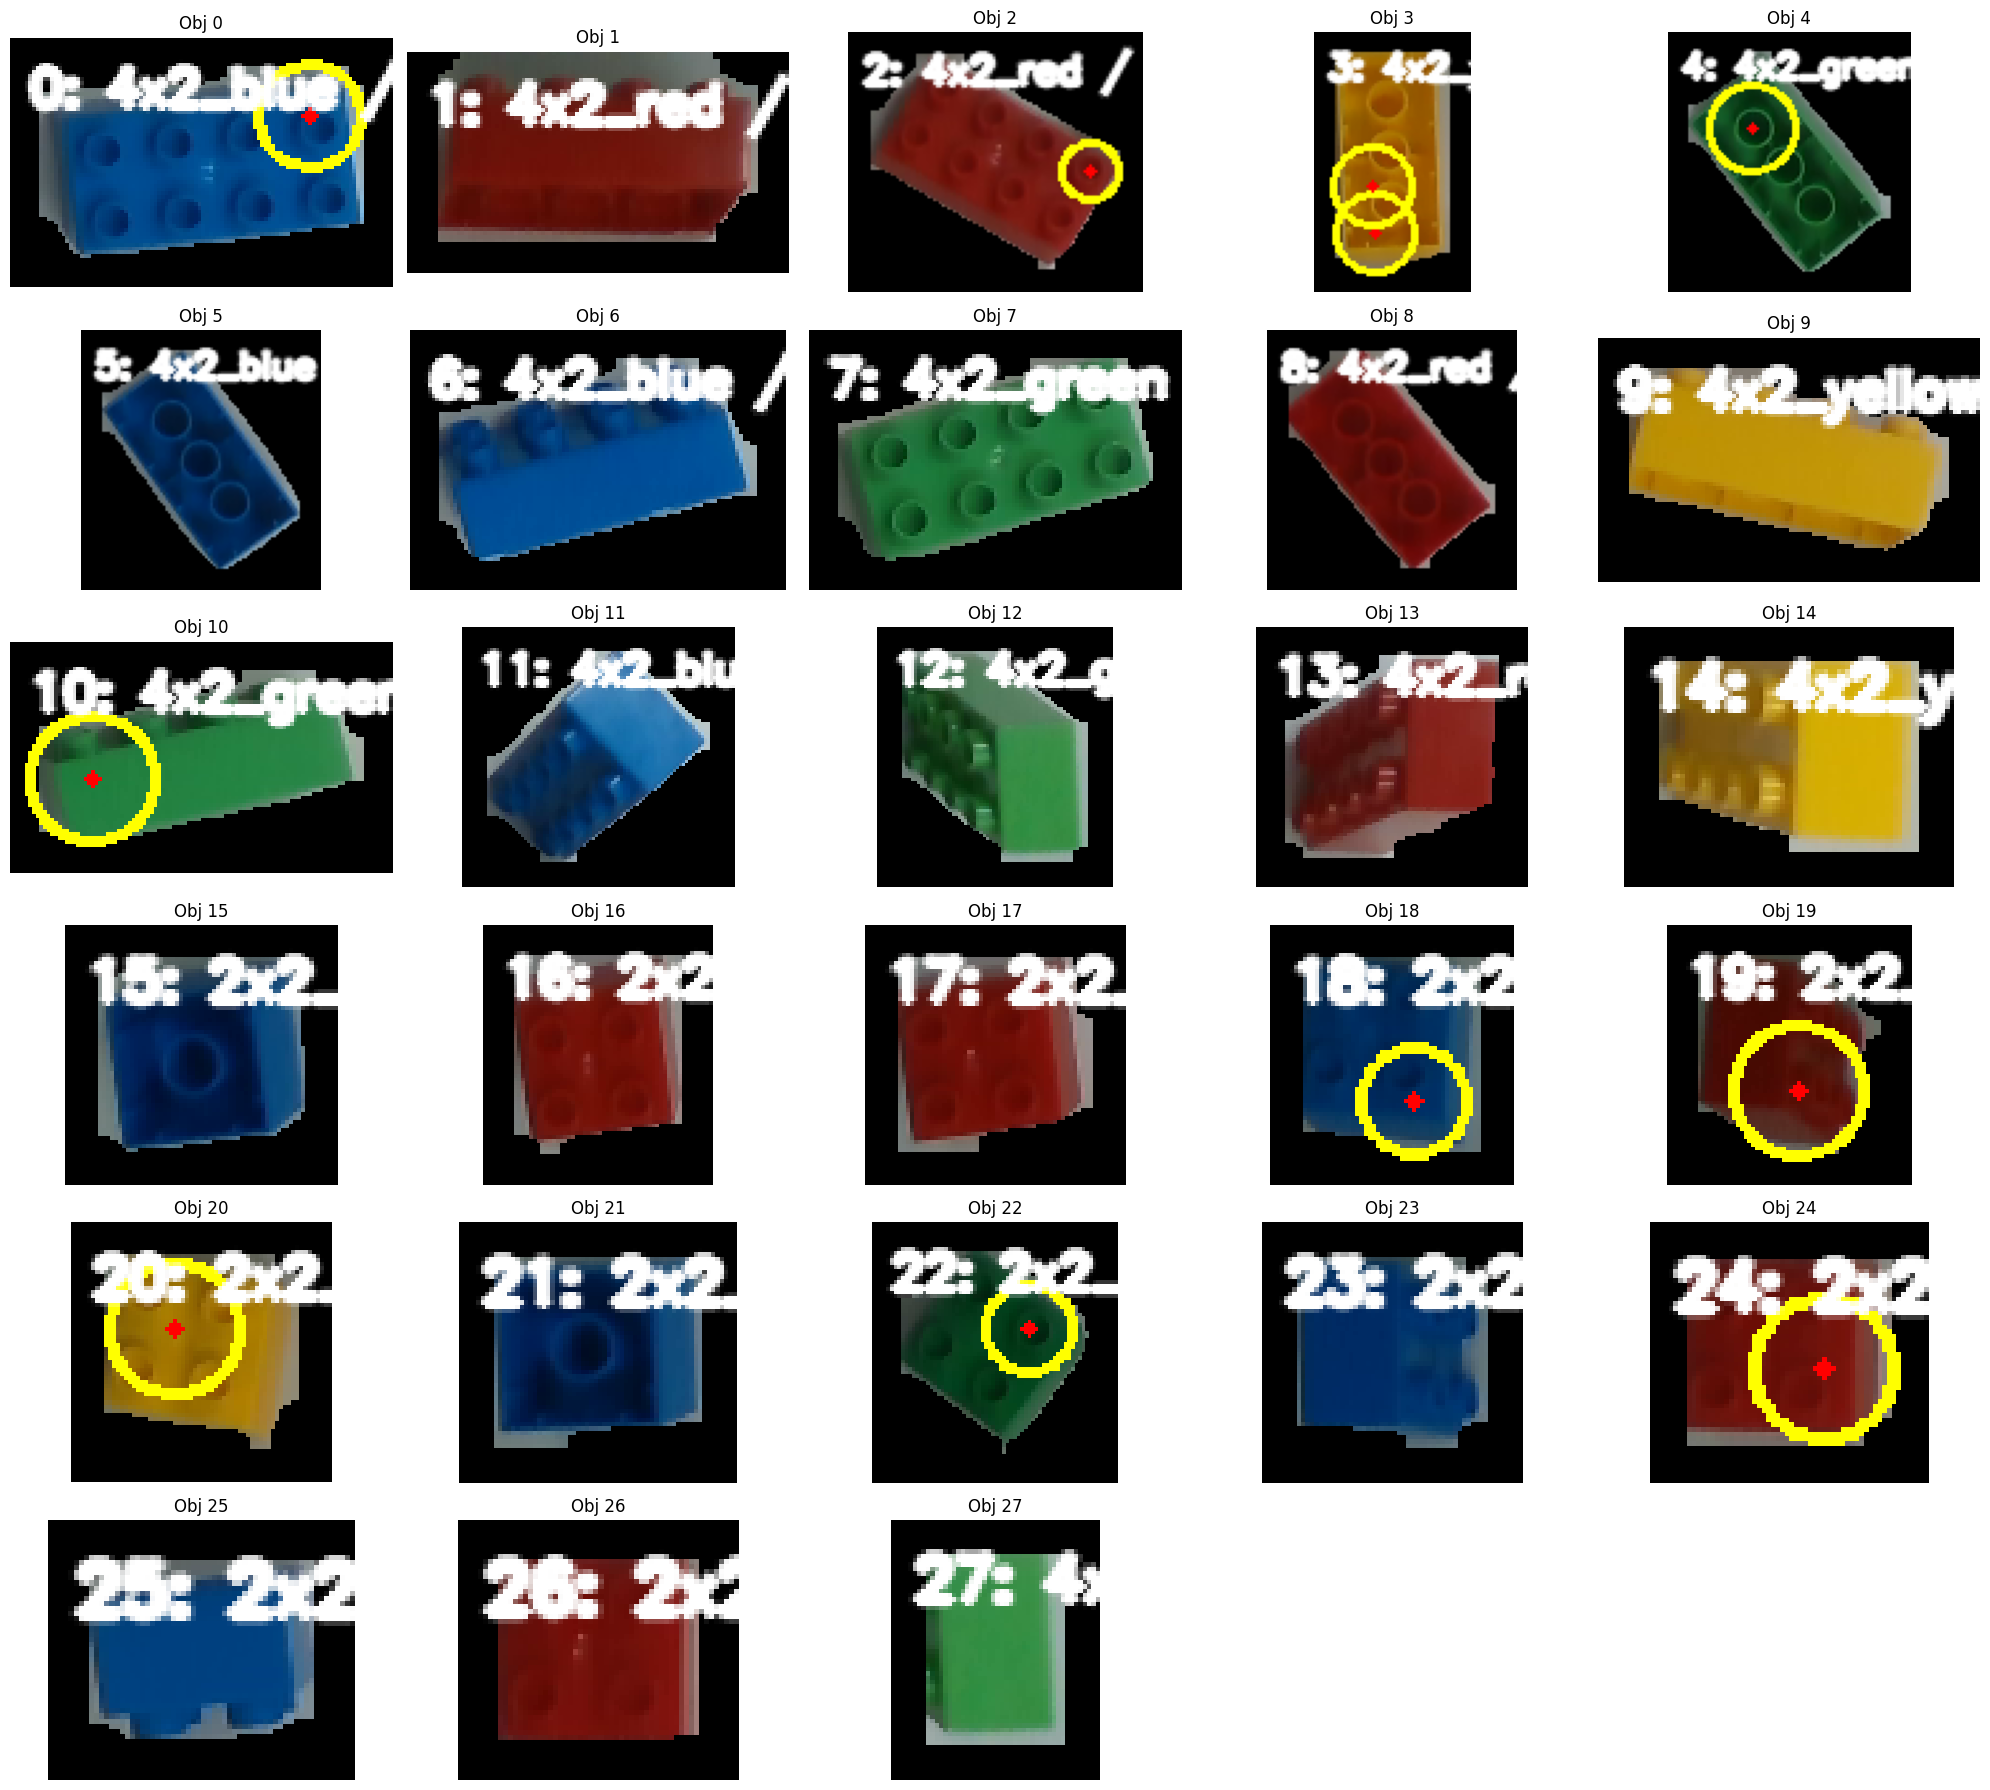

In [ ]:
circle_results, vis_hough_all, masked_color_bgr, vis_hough_masked = detect_hough_circles_in_objects(
    color_img_bgr=color_img_bgr,
    objects=objects_filled,   # 내부 채운 최종 객체 마스크 사용
    dp=1.2,
    min_dist=18,
    param1=80,
    param2=18,
    min_radius=4,
    max_radius=18,
    blur_ksize=5,
    morph_close=True,
    show=True
)